# M-02 — Mecânica Quântica: de Planck a Dirac

- **Tipo:** Matemática
- **Vínculo:** [D-00](../digressoes/D-00.ipynb), [D-06](../digressoes/D-06.ipynb) — fundação física do qubit
- **Pré-requisito:** [M-00](M-00.ipynb) (espaços vetoriais), [M-01](M-01.ipynb) (Hamiltoniano)

<div style="border-left: 2px solid #6b7280; padding: 0.5em 1em 0.5em 1.1em; margin: 0.8em 0 1.2em 0; background: rgba(107, 114, 128, 0.05); border-radius: 0 3px 3px 0;">
  <span style="font-size: 0.65em; font-weight: 700; letter-spacing: 0.13em; text-transform: uppercase; color: #9ca3af;">etimologia</span><br>
  <span style="font-size: 0.88em; line-height: 1.65;"><b>Quantum</b> vem do latim <i>quantum</i>, "quanto", "o quanto". Planck usou o termo para descrever a menor porção de energia que um oscilador pode emitir ou absorver — um pacote indivisível. A ideia de que a natureza vem em porções discretas, não contínuas, é o núcleo da revolução quântica.<br></span>
  
  <span style="font-size: 0.88em; line-height: 1.65;"><b>Espectro</b> vem do latim <i>spectrum</i>, "aparição", "imagem" — de <i>specere</i> ("ver", "observar"). Newton usou a palavra para descrever a decomposição da luz branca em cores pelo prisma. Em mecânica quântica, o espectro de um operador é o conjunto de seus possíveis valores de medição — o que o sistema pode "mostrar" quando observado.</span>
</div>

## Introdução

A mecânica quântica não foi inventada por alguém que queria uma teoria nova — foi forçada por experimentos que a mecânica clássica não conseguia explicar. Este notebook reconstrói os três experimentos que quebraram a física clássica e mostra como as soluções propostas convergiram para o formalismo que usamos hoje: o formalismo de Dirac, que é a linguagem nativa do qubit.

## 1. Os três experimentos que quebraram a física clássica

*Esqueleto — expandir aqui*

**1.1 Radiação de corpo negro (Planck, 1900)**
- O problema: a física clássica previa que um corpo aquecido emite energia infinita em frequências altas — a `catástrofe ultravioleta`. Nenhum experimento confirmava isso.
- A solução de Planck: postular que a energia é emitida em pacotes discretos $E = h\nu$. Não era uma teoria — era um truque matemático que funcionou.
- Consequência: a energia é `quantizada`. Isso não fazia sentido clássico, mas descrevia os dados.

**1.2 Efeito fotoelétrico (Einstein, 1905)**
- O problema: luz abaixo de certa frequência não arranca elétrons de uma superfície metálica, independente da intensidade. A física clássica previa que intensidade suficiente sempre funcionaria.
- A solução de Einstein: a luz é feita de `fótons` com energia $E = h\nu$. Para arrancar um elétron, o fóton precisa ter energia mínima — e isso depende da frequência, não da intensidade.
- Consequência: luz tem comportamento de partícula. Mas Young já havia mostrado que luz tem comportamento de onda. Surge a `dualidade onda-partícula`.

**1.3 Modelo atômico de Bohr (1913) e espectros discretos**
- O problema: átomos excitados emitem luz em frequências específicas (espectros discretos), não numa distribuição contínua.
- A solução de Bohr: postular que os elétrons só ocupam órbitas com `momento angular quantizado`. As transições entre órbitas emitem fótons com energia igual à diferença de níveis.
- Consequência: a energia dos elétrons no átomo é discreta. Isso exige uma teoria onde estados de energia são discretos por construção.

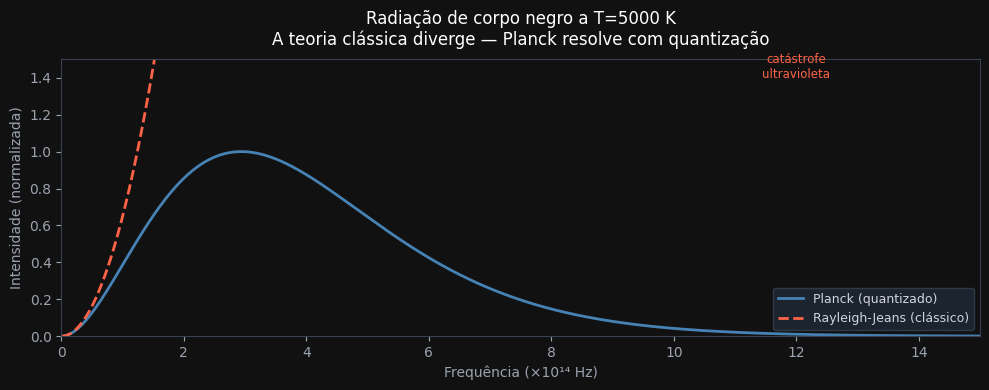

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ── Radiação de corpo negro: clássico vs. Planck ─────────────────────────────
h  = 6.626e-34   # constante de Planck (J·s)
c  = 3e8         # velocidade da luz (m/s)
kB = 1.381e-23   # constante de Boltzmann (J/K)
T  = 5000        # temperatura (K)

nu = np.linspace(1e12, 1.5e15, 2000)   # frequências (Hz)

# Lei de Rayleigh-Jeans (clássica): diverge em altas frequências
I_classico = 2 * kB * T * nu**2 / c**2

# Lei de Planck
I_planck = (2 * h * nu**3 / c**2) / (np.exp(h * nu / (kB * T)) - 1)

fig, ax = plt.subplots(figsize=(10, 4), facecolor='#111')
fig.patch.set_facecolor('#111')
ax.set_facecolor('#111')
ax.tick_params(colors='#9ca3af')
for spine in ax.spines.values():
    spine.set_edgecolor('#374151')

ax.plot(nu / 1e14, I_planck / I_planck.max(), color='steelblue', lw=2, label='Planck (quantizado)')
ax.plot(nu / 1e14, np.clip(I_classico / I_planck.max(), 0, 2), color='tomato',
        lw=2, ls='--', label='Rayleigh-Jeans (clássico)')
ax.set_xlim(0, 15)
ax.set_ylim(0, 1.5)
ax.set_xlabel('Frequência (×10¹⁴ Hz)', color='#9ca3af')
ax.set_ylabel('Intensidade (normalizada)', color='#9ca3af')
ax.set_title(f'Radiação de corpo negro a T={T} K\nA teoria clássica diverge — Planck resolve com quantização', color='white', pad=10)
ax.legend(fontsize=9, labelcolor='#d1d5db', facecolor='#1f2937', edgecolor='#374151')

ax.annotate('catástrofe\nultravioleta', xy=(12, 1.4), color='tomato', fontsize=8.5, ha='center')
plt.tight_layout()
plt.show()

## 2. De Bohr a Schrödinger: a equação de onda

*Esqueleto — expandir aqui*

Ideias centrais a desenvolver:

- **De Broglie (1924):** se Einstein mostrou que fótons (ondas) têm propriedades de partícula, talvez partículas tenham propriedades de onda. Comprimento de onda $\lambda = h/p$.
- **Schrödinger (1926):** escreve a equação de onda para a função $\psi(x, t)$ que descreve a partícula. A `equação de Schrödinger` é:
  $$i\hbar \frac{\partial \psi}{\partial t} = \hat{H}\psi = \left(-\frac{\hbar^2}{2m}\nabla^2 + V(x)\right)\psi$$
- `Interpretação de Born (1926):` $|\psi(x, t)|^2$ é a densidade de probabilidade de encontrar a partícula na posição $x$ no instante $t$.
- Mostrar: para poço infinito de potencial, autofunções são senoidais e autovalores são discretos $E_n = n^2\pi^2\hbar^2/2mL^2$.

## 3. O formalismo de Dirac

*Esqueleto — expandir aqui*

Ideias centrais a desenvolver:

- Heisenberg (1925) tinha desenvolvido uma formulação em matrizes; Schrödinger em ondas. Dirac (1930) mostrou que são equivalentes e criou a notação que unifica tudo.
- `Notação de Dirac (bra-ket)`: $|\psi\rangle$ é um vetor de estado (ket), $\langle\psi|$ é seu dual (bra), $\langle\phi|\psi\rangle$ é o produto interno.
- Os `postulados` da mecânica quântica no formalismo de Dirac:
  1. O estado de um sistema é um vetor $|\psi\rangle$ num espaço de Hilbert
  2. Observáveis são operadores Hermitianos
  3. Autovalores de um observável são os únicos resultados possíveis de medição
  4. Após medir e obter $\lambda_k$, o estado colapsa para $|\lambda_k\rangle$
  5. A evolução temporal é $|\psi(t)\rangle = e^{-i\hat{H}t/\hbar}|\psi(0)\rangle$
- Conectar com N-01: tudo que aparece lá — estado, operador, medição — são esses postulados em ação.

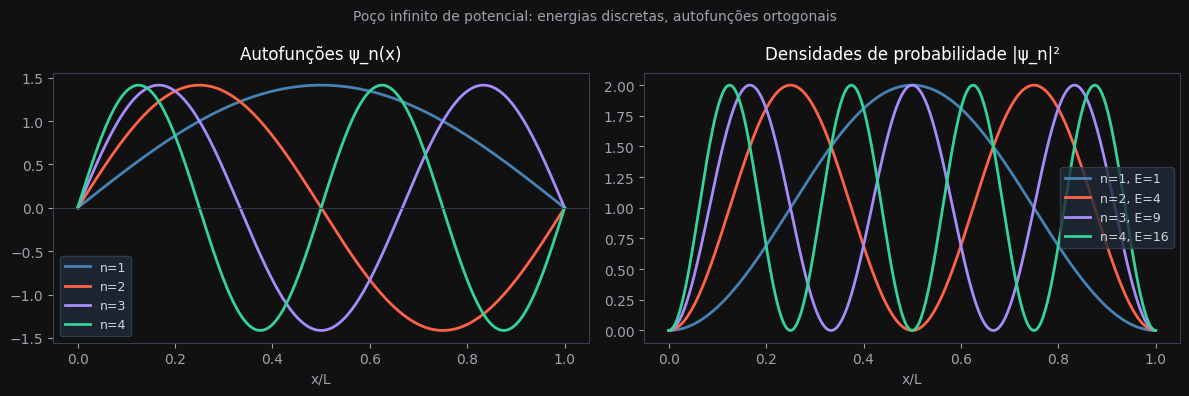

Autovalores discretos: E_n = n² × (π²ℏ²/2mL²)
Os estados são ortogonais: ∫ψ_m(x)ψ_n(x)dx = δ_mn


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ── Poço infinito de potencial: autofunções e autovalores ────────────────────
# Solução analítica: ψ_n(x) = √(2/L) * sin(nπx/L),  E_n = n²π²ℏ²/2mL²

L = 1.0   # largura do poço (unidades adimensionais)
x = np.linspace(0, L, 500)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), facecolor='#111')
fig.patch.set_facecolor('#111')
colors = ['steelblue', 'tomato', '#a78bfa', '#34d399']

for ax in axes:
    ax.set_facecolor('#111')
    ax.tick_params(colors='#9ca3af')
    for spine in ax.spines.values():
        spine.set_edgecolor('#374151')

for n, color in enumerate([1, 2, 3, 4], start=1):
    psi_n = np.sqrt(2/L) * np.sin(n * np.pi * x / L)
    E_n = n**2   # em unidades de π²ℏ²/2mL²

    axes[0].plot(x, psi_n, color=colors[n-1], lw=2, label=f'n={n}')
    axes[1].plot(x, psi_n**2, color=colors[n-1], lw=2, label=f'n={n}, E={E_n}')

axes[0].set_title('Autofunções ψ_n(x)', color='white', pad=10)
axes[0].set_xlabel('x/L', color='#9ca3af')
axes[0].axhline(0, color='#374151', lw=0.6)
axes[0].legend(fontsize=9, labelcolor='#d1d5db', facecolor='#1f2937', edgecolor='#374151')

axes[1].set_title('Densidades de probabilidade |ψ_n|²', color='white', pad=10)
axes[1].set_xlabel('x/L', color='#9ca3af')
axes[1].legend(fontsize=9, labelcolor='#d1d5db', facecolor='#1f2937', edgecolor='#374151')

plt.suptitle('Poço infinito de potencial: energias discretas, autofunções ortogonais',
             color='#9ca3af', fontsize=10)
plt.tight_layout()
plt.show()

print('Autovalores discretos: E_n = n² × (π²ℏ²/2mL²)')
print('Os estados são ortogonais: ∫ψ_m(x)ψ_n(x)dx = δ_mn')

## 4. O princípio da incerteza revisitado

*Esqueleto — expandir aqui*

Ideias centrais a desenvolver:

- Com o formalismo de Dirac, o princípio da incerteza é uma consequência direta do comutador $[\hat{x}, \hat{p}] = i\hbar$.
- `Desigualdade de Robertson`: para quaisquer dois observáveis $\hat{A}$ e $\hat{B}$:
  $$\Delta A \, \Delta B \geq \frac{1}{2}|\langle[\hat{A}, \hat{B}]\rangle|$$
- Para $\hat{x}$ e $\hat{p}$: $\Delta x \, \Delta p \geq \hbar/2$.
- Mostrar com `pacote gaussiano`: o mínimo de incerteza é atingido precisamente pelo gaussiano — $\Delta x \cdot \Delta p = \hbar/2$.

<a href="../digressoes/D-06.ipynb" style="font-size: 0.82em; color: #6b7280; text-decoration: none; border-bottom: 1px dashed #6b7280; white-space: nowrap;">↳ D-06 — O Princípio da Incerteza</a>

## Por que isso importa para algoritmos quânticos

Os postulados de Dirac são o contrato que todo algoritmo quântico cumpre:

- **Estado inicial:** preparar $|0\rangle^{\otimes n}$ é preparar o estado de energia mais baixo de cada qubit.
- **Evolução:** aplicar portas é implementar $e^{-i\hat{H}t}$ para Hamiltonianos específicos.
- **Medição:** ler o resultado é aplicar a regra de Born — o colapso para um autovalor é irreversível.
- **Interferência:** funciona porque as amplitudes são complexas e se somam antes da medição.

Sem os postulados, não há como responder: por que o algoritmo de Grover funciona? Por que QPE extrai o espectro? A resposta está sempre nos postulados.